# 4. Non-stationary Transformer

This notebook implements the Non-stationary Transformer (NeurIPS 2022) for electricity load forecasting. The key innovation over a vanilla Transformer is two modules:

1. **Series Stationarization**: normalizes each input window by its own mean/std, then de-normalizes the output. This makes the model equivariant to distributional shifts.
2. **De-stationary Attention**: recovers the non-stationary information lost during normalization by learning scaling factor `tau` and shifting vector `delta` via a small MLP projector, then injecting them into the attention scores.

We follow the same cluster-level architecture as the other notebooks: one model per behavioral cluster, with client-level forecasts obtained by volume scaling.

## 1. Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
import gc
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

warnings.filterwarnings("ignore")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11})

# ---------------------------------------------------------
# Device selection: MPS (Apple Silicon) > CUDA > CPU
# ---------------------------------------------------------
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# ---------------------------------------------------------
# Load only the columns we need (RAM-conscious on 16GB M4 Air)
# ---------------------------------------------------------
print("Loading processed data...")
needed_cols = ['Date', 'ClientID', 'Consumption', 'Cluster',
               'HDH', 'CDH', 'HDH_lag24h', 'CDH_lag24h',
               'HDH_anomaly', 'CDH_anomaly',
               'Weekday', 'Hour', 'Is_Weekend', 'Is_Holiday']

df_full = pd.read_parquet('../Datasets/processed_electricity_data.parquet')
available_cols = [c for c in needed_cols if c in df_full.columns]
df_long = df_full[available_cols].copy()
del df_full
gc.collect()

cluster_map = df_long[['ClientID', 'Cluster']].drop_duplicates()
print(f"Loaded {len(df_long):,} rows | {df_long['ClientID'].nunique()} clients")

Using device: mps
Loading processed data...
Loaded 41,548,234 rows | 369 clients


## 2. Cluster-Level Hourly Aggregation

We aggregate each cluster's consumption to an hourly average (same as SARIMAX) to keep input sequences manageable. For a Transformer with `seq_len=168` (7 days of hourly data) predicting `pred_len=24` (1 day ahead), we need ~26k hourly training samples per cluster — more than enough.

**Features per timestep (C=7):** Consumption, HDH, CDH, HDH_lag24h, CDH_lag24h, HDH_anomaly, CDH_anomaly

In [2]:
# ---------------------------------------------------------
# Hyperparameters
# ---------------------------------------------------------
SPLIT_DATE    = '2014-01-01'
SEQ_LEN       = 168    # Input window: 7 days of hourly data
LABEL_LEN     = 24     # Decoder overlap with encoder (last 24h of input)
PRED_LEN      = 24     # Forecast horizon: 24 hours ahead
D_MODEL       = 128    # Embedding dimension (small for 16GB RAM)
N_HEADS       = 4
E_LAYERS      = 2      # Encoder layers
D_LAYERS      = 1      # Decoder layers
D_FF          = 256    # Feed-forward hidden dimension
DROPOUT       = 0.1
P_HIDDEN_DIMS = [64]   # Projector MLP hidden dims (learns tau, delta)
BATCH_SIZE    = 32
LEARNING_RATE = 1e-4
EPOCHS        = 10
PATIENCE      = 3      # Early stopping patience

# Feature columns (multivariate: Consumption + 6 weather features)
FEATURE_COLS = ['Consumption', 'HDH', 'CDH', 'HDH_lag24h', 'CDH_lag24h', 'HDH_anomaly', 'CDH_anomaly']
ENC_IN = len(FEATURE_COLS)  # 7 input variables
C_OUT  = 1                  # Predict only Consumption

# ---------------------------------------------------------
# Aggregate to hourly cluster-level series
# ---------------------------------------------------------
print("Aggregating to hourly cluster-level series...")
unique_clusters = sorted(df_long['Cluster'].dropna().unique())

cluster_data = {}
for cluster_id in unique_clusters:
    mask = df_long['Cluster'] == cluster_id
    valid_features = [c for c in FEATURE_COLS if c in df_long.columns]
    
    df_c = (
        df_long.loc[mask, ['Date'] + valid_features]
        .set_index('Date')
        .sort_index()
        .astype(float)
        .resample('h')
        .mean()
        .ffill()
        .dropna()
    )
    cluster_data[cluster_id] = df_c
    print(f"  Cluster {int(cluster_id)}: {len(df_c)} hourly steps, "
          f"train={len(df_c[df_c.index < SPLIT_DATE])}, test={len(df_c[df_c.index >= SPLIT_DATE])}")

# Free df_long to save RAM (we only need cluster_data from here)
del df_long
gc.collect()
print("Done.")

Aggregating to hourly cluster-level series...
  Cluster 0: 26137 hourly steps, train=17376, test=8761
  Cluster 1: 34897 hourly steps, train=26136, test=8761
  Cluster 2: 34897 hourly steps, train=26136, test=8761
  Cluster 3: 34897 hourly steps, train=26136, test=8761
  Cluster 4: 34897 hourly steps, train=26136, test=8761
Done.


## 3. Dataset, Time Features, and Model Architecture

We implement the full Non-stationary Transformer from the paper:
- **DataEmbedding**: value projection + positional encoding + temporal encoding
- **Projector**: small MLP that learns de-stationary factors `tau` (scaling) and `delta` (shifting) from the raw (un-normalized) input statistics
- **DSAttention**: De-stationary Attention that rescales the pre-softmax scores with `tau * Q'K' + delta`
- **Series Stationarization**: instance normalization (subtract mean, divide by std) on input, reverse on output

In [3]:
# =============================================================
# SLIDING WINDOW DATASET
# =============================================================
class TimeSeriesDataset(Dataset):
    """Creates (encoder_input, decoder_input, target) sliding windows."""
    
    def __init__(self, data: np.ndarray, seq_len: int, label_len: int, pred_len: int, freq='h'):
        self.data     = data.astype(np.float32)
        self.seq_len  = seq_len
        self.label_len = label_len
        self.pred_len  = pred_len
        self.freq      = freq
        
    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1
    
    def __getitem__(self, idx):
        s_begin = idx
        s_end   = s_begin + self.seq_len
        r_begin = s_end - self.label_len
        r_end   = r_begin + self.label_len + self.pred_len
        
        seq_x = self.data[s_begin:s_end]           # Encoder input: (seq_len, C)
        seq_y = self.data[r_begin:r_end]            # Decoder input: (label_len + pred_len, C)
        
        # Time features: simple positional indices normalized to [-0.5, 0.5]
        seq_x_mark = self._time_features(s_begin, s_end)
        seq_y_mark = self._time_features(r_begin, r_end)
        
        return (torch.tensor(seq_x), torch.tensor(seq_y),
                torch.tensor(seq_x_mark), torch.tensor(seq_y_mark))
    
    def _time_features(self, start, end):
        """Generate hour-of-day and day-of-week features for the index range."""
        length = end - start
        hours = np.arange(start, end) % 24 / 23.0 - 0.5
        days  = (np.arange(start, end) // 24) % 7 / 6.0 - 0.5
        return np.stack([hours, days], axis=-1).astype(np.float32)


# =============================================================
# POSITIONAL ENCODING
# =============================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return self.pe[:, :x.size(1)]


# =============================================================
# DATA EMBEDDING (value projection + positional + temporal)
# =============================================================
class DataEmbedding(nn.Module):
    def __init__(self, c_in, d_model, n_time_features=2, dropout=0.1):
        super().__init__()
        self.value_embedding = nn.Linear(c_in, d_model)
        self.position_encoding = PositionalEncoding(d_model)
        self.temporal_embedding = nn.Linear(n_time_features, d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, x_mark):
        out = self.value_embedding(x) + self.position_encoding(x) + self.temporal_embedding(x_mark)
        return self.dropout(out)


# =============================================================
# DE-STATIONARY ATTENTION (Equation 6 from the paper)
# =============================================================
class DSAttention(nn.Module):
    def __init__(self, mask_flag=True, scale=None, dropout=0.1):
        super().__init__()
        self.scale = scale
        self.mask_flag = mask_flag
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, queries, keys, values, attn_mask=None, tau=None, delta=None):
        B, L, H, E = queries.shape
        _, S, _, D = values.shape
        scale = self.scale or 1.0 / math.sqrt(E)
        
        # De-stationary factors (Equation 6)
        tau   = 1.0 if tau is None else tau.unsqueeze(1).unsqueeze(1)    # B x 1 x 1 x 1
        delta = 0.0 if delta is None else delta.unsqueeze(1).unsqueeze(1)  # B x 1 x 1 x S
        
        scores = torch.einsum("blhe,bshe->bhls", queries, keys) * tau + delta
        
        if self.mask_flag and attn_mask is not None:
            scores.masked_fill_(attn_mask, -1e9)
        
        A = self.dropout(torch.softmax(scale * scores, dim=-1))
        V = torch.einsum("bhls,bshd->blhd", A, values)
        return V.contiguous(), A


# =============================================================
# ATTENTION LAYER (projection wrapper around DSAttention)
# =============================================================
class AttentionLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        d_keys = d_model // n_heads
        self.inner_attention = DSAttention(mask_flag=False, dropout=dropout)
        self.query_projection = nn.Linear(d_model, d_keys * n_heads)
        self.key_projection   = nn.Linear(d_model, d_keys * n_heads)
        self.value_projection = nn.Linear(d_model, d_keys * n_heads)
        self.out_projection   = nn.Linear(d_keys * n_heads, d_model)
        self.n_heads = n_heads
    
    def forward(self, queries, keys, values, attn_mask=None, tau=None, delta=None):
        B, L, _ = queries.shape
        _, S, _ = keys.shape
        H = self.n_heads
        
        queries = self.query_projection(queries).view(B, L, H, -1)
        keys    = self.key_projection(keys).view(B, S, H, -1)
        values  = self.value_projection(values).view(B, S, H, -1)
        
        out, attn = self.inner_attention(queries, keys, values, attn_mask, tau, delta)
        out = out.view(B, L, -1)
        return self.out_projection(out), attn


# =============================================================
# ENCODER LAYER + ENCODER
# =============================================================
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attention = AttentionLayer(d_model, n_heads, dropout)
        self.conv1 = nn.Conv1d(d_model, d_ff, 1)
        self.conv2 = nn.Conv1d(d_ff, d_model, 1)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, attn_mask=None, tau=None, delta=None):
        new_x, _ = self.attention(x, x, x, attn_mask, tau, delta)
        x = x + self.dropout(new_x)
        y = x = self.norm1(x)
        y = self.dropout(F.gelu(self.conv1(y.transpose(-1, 1))))
        y = self.dropout(self.conv2(y).transpose(-1, 1))
        return self.norm2(x + y)


class Encoder(nn.Module):
    def __init__(self, layers, norm_layer=None):
        super().__init__()
        self.layers = nn.ModuleList(layers)
        self.norm = norm_layer
    
    def forward(self, x, attn_mask=None, tau=None, delta=None):
        for layer in self.layers:
            x = layer(x, attn_mask, tau, delta)
        if self.norm:
            x = self.norm(x)
        return x


# =============================================================
# DECODER LAYER + DECODER
# =============================================================
class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attention  = AttentionLayer(d_model, n_heads, dropout)
        self.cross_attention = AttentionLayer(d_model, n_heads, dropout)
        self.conv1 = nn.Conv1d(d_model, d_ff, 1)
        self.conv2 = nn.Conv1d(d_ff, d_model, 1)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, cross, x_mask=None, cross_mask=None, tau=None, delta=None):
        # Self-attention on decoder (no delta — Section 3.2 / Appendix E.2)
        x = x + self.dropout(self.self_attention(x, x, x, x_mask, tau, None)[0])
        x = self.norm1(x)
        # Cross-attention with encoder output (with delta)
        x = x + self.dropout(self.cross_attention(x, cross, cross, cross_mask, tau, delta)[0])
        y = x = self.norm2(x)
        y = self.dropout(F.gelu(self.conv1(y.transpose(-1, 1))))
        y = self.dropout(self.conv2(y).transpose(-1, 1))
        return self.norm3(x + y)


class Decoder(nn.Module):
    def __init__(self, layers, norm_layer=None, projection=None):
        super().__init__()
        self.layers = nn.ModuleList(layers)
        self.norm = norm_layer
        self.projection = projection
    
    def forward(self, x, cross, x_mask=None, cross_mask=None, tau=None, delta=None):
        for layer in self.layers:
            x = layer(x, cross, x_mask, cross_mask, tau, delta)
        if self.norm:
            x = self.norm(x)
        if self.projection:
            x = self.projection(x)
        return x


# =============================================================
# PROJECTOR (learns de-stationary factors tau and delta)
# =============================================================
class Projector(nn.Module):
    def __init__(self, enc_in, seq_len, hidden_dims, output_dim, kernel_size=3):
        super().__init__()
        padding = 1 if torch.__version__ >= '1.5.0' else 2
        self.series_conv = nn.Conv1d(seq_len, 1, kernel_size, padding=padding,
                                     padding_mode='circular', bias=False)
        layers = [nn.Linear(2 * enc_in, hidden_dims[0]), nn.ReLU()]
        for i in range(len(hidden_dims) - 1):
            layers += [nn.Linear(hidden_dims[i], hidden_dims[i+1]), nn.ReLU()]
        layers += [nn.Linear(hidden_dims[-1], output_dim, bias=False)]
        self.backbone = nn.Sequential(*layers)
    
    def forward(self, x, stats):
        # x: B x S x E, stats: B x 1 x E -> y: B x O
        batch_size = x.shape[0]
        x = self.series_conv(x)             # B x 1 x E
        x = torch.cat([x, stats], dim=1)    # B x 2 x E
        x = x.view(batch_size, -1)          # B x 2E
        return self.backbone(x)             # B x O


# =============================================================
# NON-STATIONARY TRANSFORMER (Algorithm 4 from the paper)
# =============================================================
class NonStationaryTransformer(nn.Module):
    def __init__(self, enc_in, c_out, seq_len, label_len, pred_len,
                 d_model=128, n_heads=4, e_layers=2, d_layers=1,
                 d_ff=256, dropout=0.1, p_hidden_dims=[64], n_time_features=2):
        super().__init__()
        self.pred_len  = pred_len
        self.seq_len   = seq_len
        self.label_len = label_len
        
        # Embedding
        self.enc_embedding = DataEmbedding(enc_in, d_model, n_time_features, dropout)
        self.dec_embedding = DataEmbedding(enc_in, d_model, n_time_features, dropout)
        
        # Encoder
        self.encoder = Encoder(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(e_layers)],
            norm_layer=nn.LayerNorm(d_model)
        )
        
        # Decoder
        self.decoder = Decoder(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(d_layers)],
            norm_layer=nn.LayerNorm(d_model),
            projection=nn.Linear(d_model, c_out)
        )
        
        # De-stationary Projectors (learn tau and delta from raw input statistics)
        self.tau_learner   = Projector(enc_in, seq_len, p_hidden_dims, output_dim=1)
        self.delta_learner = Projector(enc_in, seq_len, p_hidden_dims, output_dim=seq_len)
    
    def forward(self, x_enc, x_mark_enc, x_dec, x_mark_dec):
        x_raw = x_enc.clone().detach()
        
        # ---------------------------------------------------------
        # Series Stationarization: Normalization (Algorithm 1)
        # ---------------------------------------------------------
        mean_enc = x_enc.mean(1, keepdim=True).detach()   # B x 1 x C
        x_enc = x_enc - mean_enc
        std_enc = torch.sqrt(torch.var(x_enc, dim=1, keepdim=True, unbiased=False) + 1e-5).detach()
        x_enc = x_enc / std_enc
        
        # Build decoder input: last label_len of normalized encoder + zeros for pred_len
        x_dec_new = torch.cat([
            x_enc[:, -self.label_len:, :],
            torch.zeros_like(x_dec[:, -self.pred_len:, :])
        ], dim=1).to(x_enc.device)
        
        # ---------------------------------------------------------
        # Learn de-stationary factors from raw (un-normalized) input
        # ---------------------------------------------------------
        tau   = self.tau_learner(x_raw, std_enc).exp()   # B x 1 (positive scalar)
        delta = self.delta_learner(x_raw, mean_enc)      # B x S
        
        # ---------------------------------------------------------
        # Encoder-Decoder with De-stationary Attention
        # ---------------------------------------------------------
        enc_out = self.enc_embedding(x_enc, x_mark_enc)
        enc_out = self.encoder(enc_out, tau=tau, delta=delta)
        
        dec_out = self.dec_embedding(x_dec_new, x_mark_dec)
        dec_out = self.decoder(dec_out, enc_out, tau=tau, delta=delta)
        
        # ---------------------------------------------------------
        # Series Stationarization: De-normalization (Algorithm 2)
        # Only restore statistics for Consumption (column 0)
        # ---------------------------------------------------------
        dec_out = dec_out * std_enc[:, :, :1] + mean_enc[:, :, :1]
        
        return dec_out[:, -self.pred_len:, :]   # B x pred_len x 1

print(f"Model architecture defined.")
print(f"  enc_in={ENC_IN}, c_out={C_OUT}, d_model={D_MODEL}, n_heads={N_HEADS}")
print(f"  seq_len={SEQ_LEN}, label_len={LABEL_LEN}, pred_len={PRED_LEN}")
print(f"  e_layers={E_LAYERS}, d_layers={D_LAYERS}, d_ff={D_FF}")

Model architecture defined.
  enc_in=7, c_out=1, d_model=128, n_heads=4
  seq_len=168, label_len=24, pred_len=24
  e_layers=2, d_layers=1, d_ff=256


## 4. Training Loop (One Model per Cluster)

We train 5 separate Non-stationary Transformer models (one per behavioral cluster). Each model is trained on pre-2014 hourly data with MSE loss, Adam optimizer, and early stopping on a chronological validation split (last 10% of training data).

In [4]:
# =============================================================
# TRAINING LOOP: ONE MODEL PER CLUSTER
# =============================================================
cluster_models_nst = {}
cluster_forecasts_nst = {}
cluster_scalers = {}

for cluster_id in unique_clusters:
    print(f"\n{'='*60}")
    print(f"  Training Non-stationary Transformer for Cluster {int(cluster_id)}")
    print(f"{'='*60}")
    
    df_c = cluster_data[cluster_id]
    valid_features = [c for c in FEATURE_COLS if c in df_c.columns]
    
    # ---------------------------------------------------------
    # Per-feature StandardScaler (fit on train only)
    # ---------------------------------------------------------
    train_df = df_c[df_c.index < SPLIT_DATE][valid_features]
    test_df  = df_c[df_c.index >= SPLIT_DATE][valid_features]
    
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_df.values)
    test_scaled  = scaler.transform(test_df.values)
    cluster_scalers[cluster_id] = scaler
    
    # Chronological val split: last 10% of training data
    val_size = max(int(len(train_scaled) * 0.1), SEQ_LEN + PRED_LEN + 1)
    train_data_np = train_scaled[:-val_size]
    val_data_np   = train_scaled[-val_size:]
    
    train_ds = TimeSeriesDataset(train_data_np, SEQ_LEN, LABEL_LEN, PRED_LEN)
    val_ds   = TimeSeriesDataset(val_data_np,   SEQ_LEN, LABEL_LEN, PRED_LEN)
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
    
    print(f"  Train: {len(train_ds)} windows | Val: {len(val_ds)} windows")
    
    # ---------------------------------------------------------
    # Initialize model
    # ---------------------------------------------------------
    model = NonStationaryTransformer(
        enc_in=len(valid_features), c_out=C_OUT,
        seq_len=SEQ_LEN, label_len=LABEL_LEN, pred_len=PRED_LEN,
        d_model=D_MODEL, n_heads=N_HEADS, e_layers=E_LAYERS, d_layers=D_LAYERS,
        d_ff=D_FF, dropout=DROPOUT, p_hidden_dims=P_HIDDEN_DIMS
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.MSELoss()
    
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Parameters: {n_params:,}")
    
    # ---------------------------------------------------------
    # Training with early stopping
    # ---------------------------------------------------------
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None
    
    for epoch in range(EPOCHS):
        # --- Train ---
        model.train()
        train_losses = []
        for batch_x, batch_y, batch_x_mark, batch_y_mark in train_loader:
            batch_x      = batch_x.to(device)
            batch_y      = batch_y.to(device)
            batch_x_mark = batch_x_mark.to(device)
            batch_y_mark = batch_y_mark.to(device)
            
            outputs = model(batch_x, batch_x_mark, batch_y, batch_y_mark)
            target  = batch_y[:, -PRED_LEN:, :1]  # Only Consumption (col 0)
            loss    = criterion(outputs, target)
            
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())
        
        # --- Validate ---
        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch_x, batch_y, batch_x_mark, batch_y_mark in val_loader:
                batch_x      = batch_x.to(device)
                batch_y      = batch_y.to(device)
                batch_x_mark = batch_x_mark.to(device)
                batch_y_mark = batch_y_mark.to(device)
                
                outputs = model(batch_x, batch_x_mark, batch_y, batch_y_mark)
                target  = batch_y[:, -PRED_LEN:, :1]
                val_losses.append(criterion(outputs, target).item())
        
        avg_train = np.mean(train_losses)
        avg_val   = np.mean(val_losses)
        print(f"  Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train:.6f} | Val Loss: {avg_val:.6f}")
        
        # Early stopping
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}")
                break
    
    # Restore best model
    if best_state:
        model.load_state_dict(best_state)
    model.eval()
    cluster_models_nst[cluster_id] = model
    
    # ---------------------------------------------------------
    # Rolling Day-Ahead Forecast on 2014 Test Set
    # Use actual observations from each completed day to forecast the next
    # ---------------------------------------------------------
    print(f"  Generating rolling day-ahead forecasts for 2014...")
    
    full_scaled = np.concatenate([train_scaled, test_scaled], axis=0)
    test_start_idx = len(train_scaled)
    n_test = len(test_scaled)
    
    all_preds = []
    
    with torch.no_grad():
        for day_offset in range(0, n_test, PRED_LEN):
            # Window ends at start of current forecast day
            window_end = test_start_idx + day_offset
            window_start = window_end - SEQ_LEN
            
            if window_start < 0 or window_end + PRED_LEN > len(full_scaled):
                break
            
            enc_input = full_scaled[window_start:window_end]
            dec_input = full_scaled[window_end - LABEL_LEN:window_end + PRED_LEN]
            
            enc_x = torch.tensor(enc_input, dtype=torch.float32).unsqueeze(0).to(device)
            dec_x = torch.tensor(dec_input, dtype=torch.float32).unsqueeze(0).to(device)
            
            enc_mark = torch.tensor(
                train_ds._time_features(window_start, window_end), dtype=torch.float32
            ).unsqueeze(0).to(device)
            dec_mark = torch.tensor(
                train_ds._time_features(window_end - LABEL_LEN, window_end + PRED_LEN), dtype=torch.float32
            ).unsqueeze(0).to(device)
            
            output = model(enc_x, enc_mark, dec_x, dec_mark)
            pred = output.squeeze(0).cpu().numpy()  # (PRED_LEN, 1)
            all_preds.append(pred)
    
    if all_preds:
        forecast_scaled = np.concatenate(all_preds, axis=0)[:n_test]
        
        # Inverse transform only the Consumption column
        dummy = np.zeros((len(forecast_scaled), len(valid_features)))
        dummy[:, 0] = forecast_scaled[:, 0]
        forecast_kw = scaler.inverse_transform(dummy)[:, 0]
        forecast_kw = np.maximum(forecast_kw, 0)
        
        # Build a pandas Series aligned to test dates
        test_dates = test_df.index[:len(forecast_kw)]
        cluster_forecasts_nst[cluster_id] = pd.Series(forecast_kw, index=test_dates)
        
        print(f"  -> Cluster {int(cluster_id)}: {len(forecast_kw)} hourly predictions generated")
    
    # Clean up GPU/MPS memory
    del train_loader, val_loader, train_ds, val_ds
    gc.collect()
    if device.type == 'mps':
        torch.mps.empty_cache()

print("\n" + "="*60)
print("All cluster models trained successfully!")


  Training Non-stationary Transformer for Cluster 0
  Train: 15448 windows | Val: 1546 windows
  Parameters: 480,945
  Epoch 1/10 | Train Loss: 0.344508 | Val Loss: 0.594831
  Epoch 2/10 | Train Loss: 0.095261 | Val Loss: 0.564583
  Epoch 3/10 | Train Loss: 0.074477 | Val Loss: 0.568899
  Epoch 4/10 | Train Loss: 0.065536 | Val Loss: 0.592584
  Epoch 5/10 | Train Loss: 0.059362 | Val Loss: 0.635501
  Early stopping at epoch 5
  Generating rolling day-ahead forecasts for 2014...
  -> Cluster 0: 8760 hourly predictions generated

  Training Non-stationary Transformer for Cluster 1
  Train: 23332 windows | Val: 2422 windows
  Parameters: 480,945
  Epoch 1/10 | Train Loss: 0.237355 | Val Loss: 0.115885
  Epoch 2/10 | Train Loss: 0.087068 | Val Loss: 0.060675
  Epoch 3/10 | Train Loss: 0.067262 | Val Loss: 0.038344
  Epoch 4/10 | Train Loss: 0.057134 | Val Loss: 0.027769
  Epoch 5/10 | Train Loss: 0.051109 | Val Loss: 0.024350
  Epoch 6/10 | Train Loss: 0.046648 | Val Loss: 0.020234
  Epoc

## 5. Client-Level Evaluation

Same approach as LR/Prophet/SARIMAX: scale the cluster's hourly forecast to each client's volume using `client_train_mean / cluster_train_mean`, resample to 15-min, and compute Portfolio WMAPE per cluster (errors cancel within each cluster at each timestamp).

In [5]:
# =============================================================
# CLIENT-LEVEL EVALUATION (same structure as LR notebook)
# =============================================================
print("Loading full data for client-level evaluation...")
df_eval_raw = pd.read_parquet('../Datasets/processed_electricity_data.parquet',
                               columns=['Date', 'ClientID', 'Consumption', 'Cluster'])

# ---------------------------------------------------------
# Pre-calculate cluster train means for volume scaling
# ---------------------------------------------------------
cluster_train_means = {}
for cid in unique_clusters:
    mask = (df_eval_raw['Cluster'] == cid) & (df_eval_raw['Date'] < SPLIT_DATE)
    cluster_train_means[cid] = df_eval_raw.loc[mask, 'Consumption'].mean()

# ---------------------------------------------------------
# Resample cluster forecasts from hourly to 15-min (ffill, same as SARIMAX)
# ---------------------------------------------------------
cluster_forecasts_15m = {}
for cid, forecast_series in cluster_forecasts_nst.items():
    cluster_forecasts_15m[cid] = forecast_series.resample('15min').ffill()

# ---------------------------------------------------------
# Evaluate each client: scale cluster forecast to client volume
# ---------------------------------------------------------
test = df_eval_raw[df_eval_raw['Date'] >= SPLIT_DATE].copy()
test['Predicted_kW'] = np.nan

for client_id in tqdm(test['ClientID'].unique(), desc="Evaluating Clients"):
    client_mask = test['ClientID'] == client_id
    client_test = test[client_mask]
    
    cluster_id = client_test['Cluster'].iloc[0]
    if pd.isna(cluster_id) or cluster_id not in cluster_forecasts_15m:
        continue
    
    # Client volume scaling factor
    client_train = df_eval_raw[(df_eval_raw['ClientID'] == client_id) & (df_eval_raw['Date'] < SPLIT_DATE)]
    if client_train.empty:
        continue
    client_scale = client_train['Consumption'].mean() / cluster_train_means[cluster_id]
    
    # Align cluster forecast to client test dates and scale
    forecast_15m = cluster_forecasts_15m[cluster_id]
    aligned = forecast_15m.reindex(client_test['Date']).ffill().values
    test.loc[client_mask, 'Predicted_kW'] = np.maximum(aligned * client_scale, 0)

test = test.dropna(subset=['Predicted_kW'])

# ---------------------------------------------------------
# PORTFOLIO WMAPE (errors cancel within each cluster at each timestamp)
# ---------------------------------------------------------
cluster_eval = test.groupby(['Cluster', 'Date'], observed=True)[['Consumption', 'Predicted_kW']].sum().reset_index()
cluster_eval['Abs_Error'] = np.abs(cluster_eval['Consumption'] - cluster_eval['Predicted_kW'])

mask_mape = cluster_eval['Consumption'] > 0.1
cluster_eval.loc[mask_mape, 'Perc_Error'] = (cluster_eval['Abs_Error'] / cluster_eval['Consumption']) * 100

print("\n--- NON-STATIONARY TRANSFORMER PERFORMANCE BY CLUSTER ---\n")

summary = cluster_eval.groupby('Cluster', observed=True).agg(
    Portfolio_MAPE=('Perc_Error', 'mean'),
    Total_Abs_Error=('Abs_Error', 'sum'),
    Total_Actual=('Consumption', 'sum')
)
summary['Portfolio_WMAPE'] = (summary['Total_Abs_Error'] / summary['Total_Actual']) * 100
summary = summary.drop(columns=['Total_Abs_Error', 'Total_Actual']).round(2)
print(summary)

global_wmape = (cluster_eval['Abs_Error'].sum() / cluster_eval['Consumption'].sum()) * 100
global_mape  = cluster_eval['Perc_Error'].mean()
print(f"\nGlobal Portfolio MAPE:  {global_mape:.2f}%")
print(f"Global Portfolio WMAPE: {global_wmape:.2f}%")

del df_eval_raw
gc.collect()

Loading full data for client-level evaluation...


Evaluating Clients: 100%|██████████| 369/369 [00:17<00:00, 20.69it/s]



--- NON-STATIONARY TRANSFORMER PERFORMANCE BY CLUSTER ---

         Portfolio_MAPE  Portfolio_WMAPE
Cluster                                 
0.0               29.61             4.35
1.0               50.62             6.11
2.0              142.31             8.80
3.0               86.16            81.36
4.0                7.78             5.39

Global Portfolio MAPE:  63.30%
Global Portfolio WMAPE: 13.62%


0

## 6. Forecasting Visualization

One representative client per cluster, last 14 days of 2014. Same visual format as the other notebooks.

Generating validation plots...


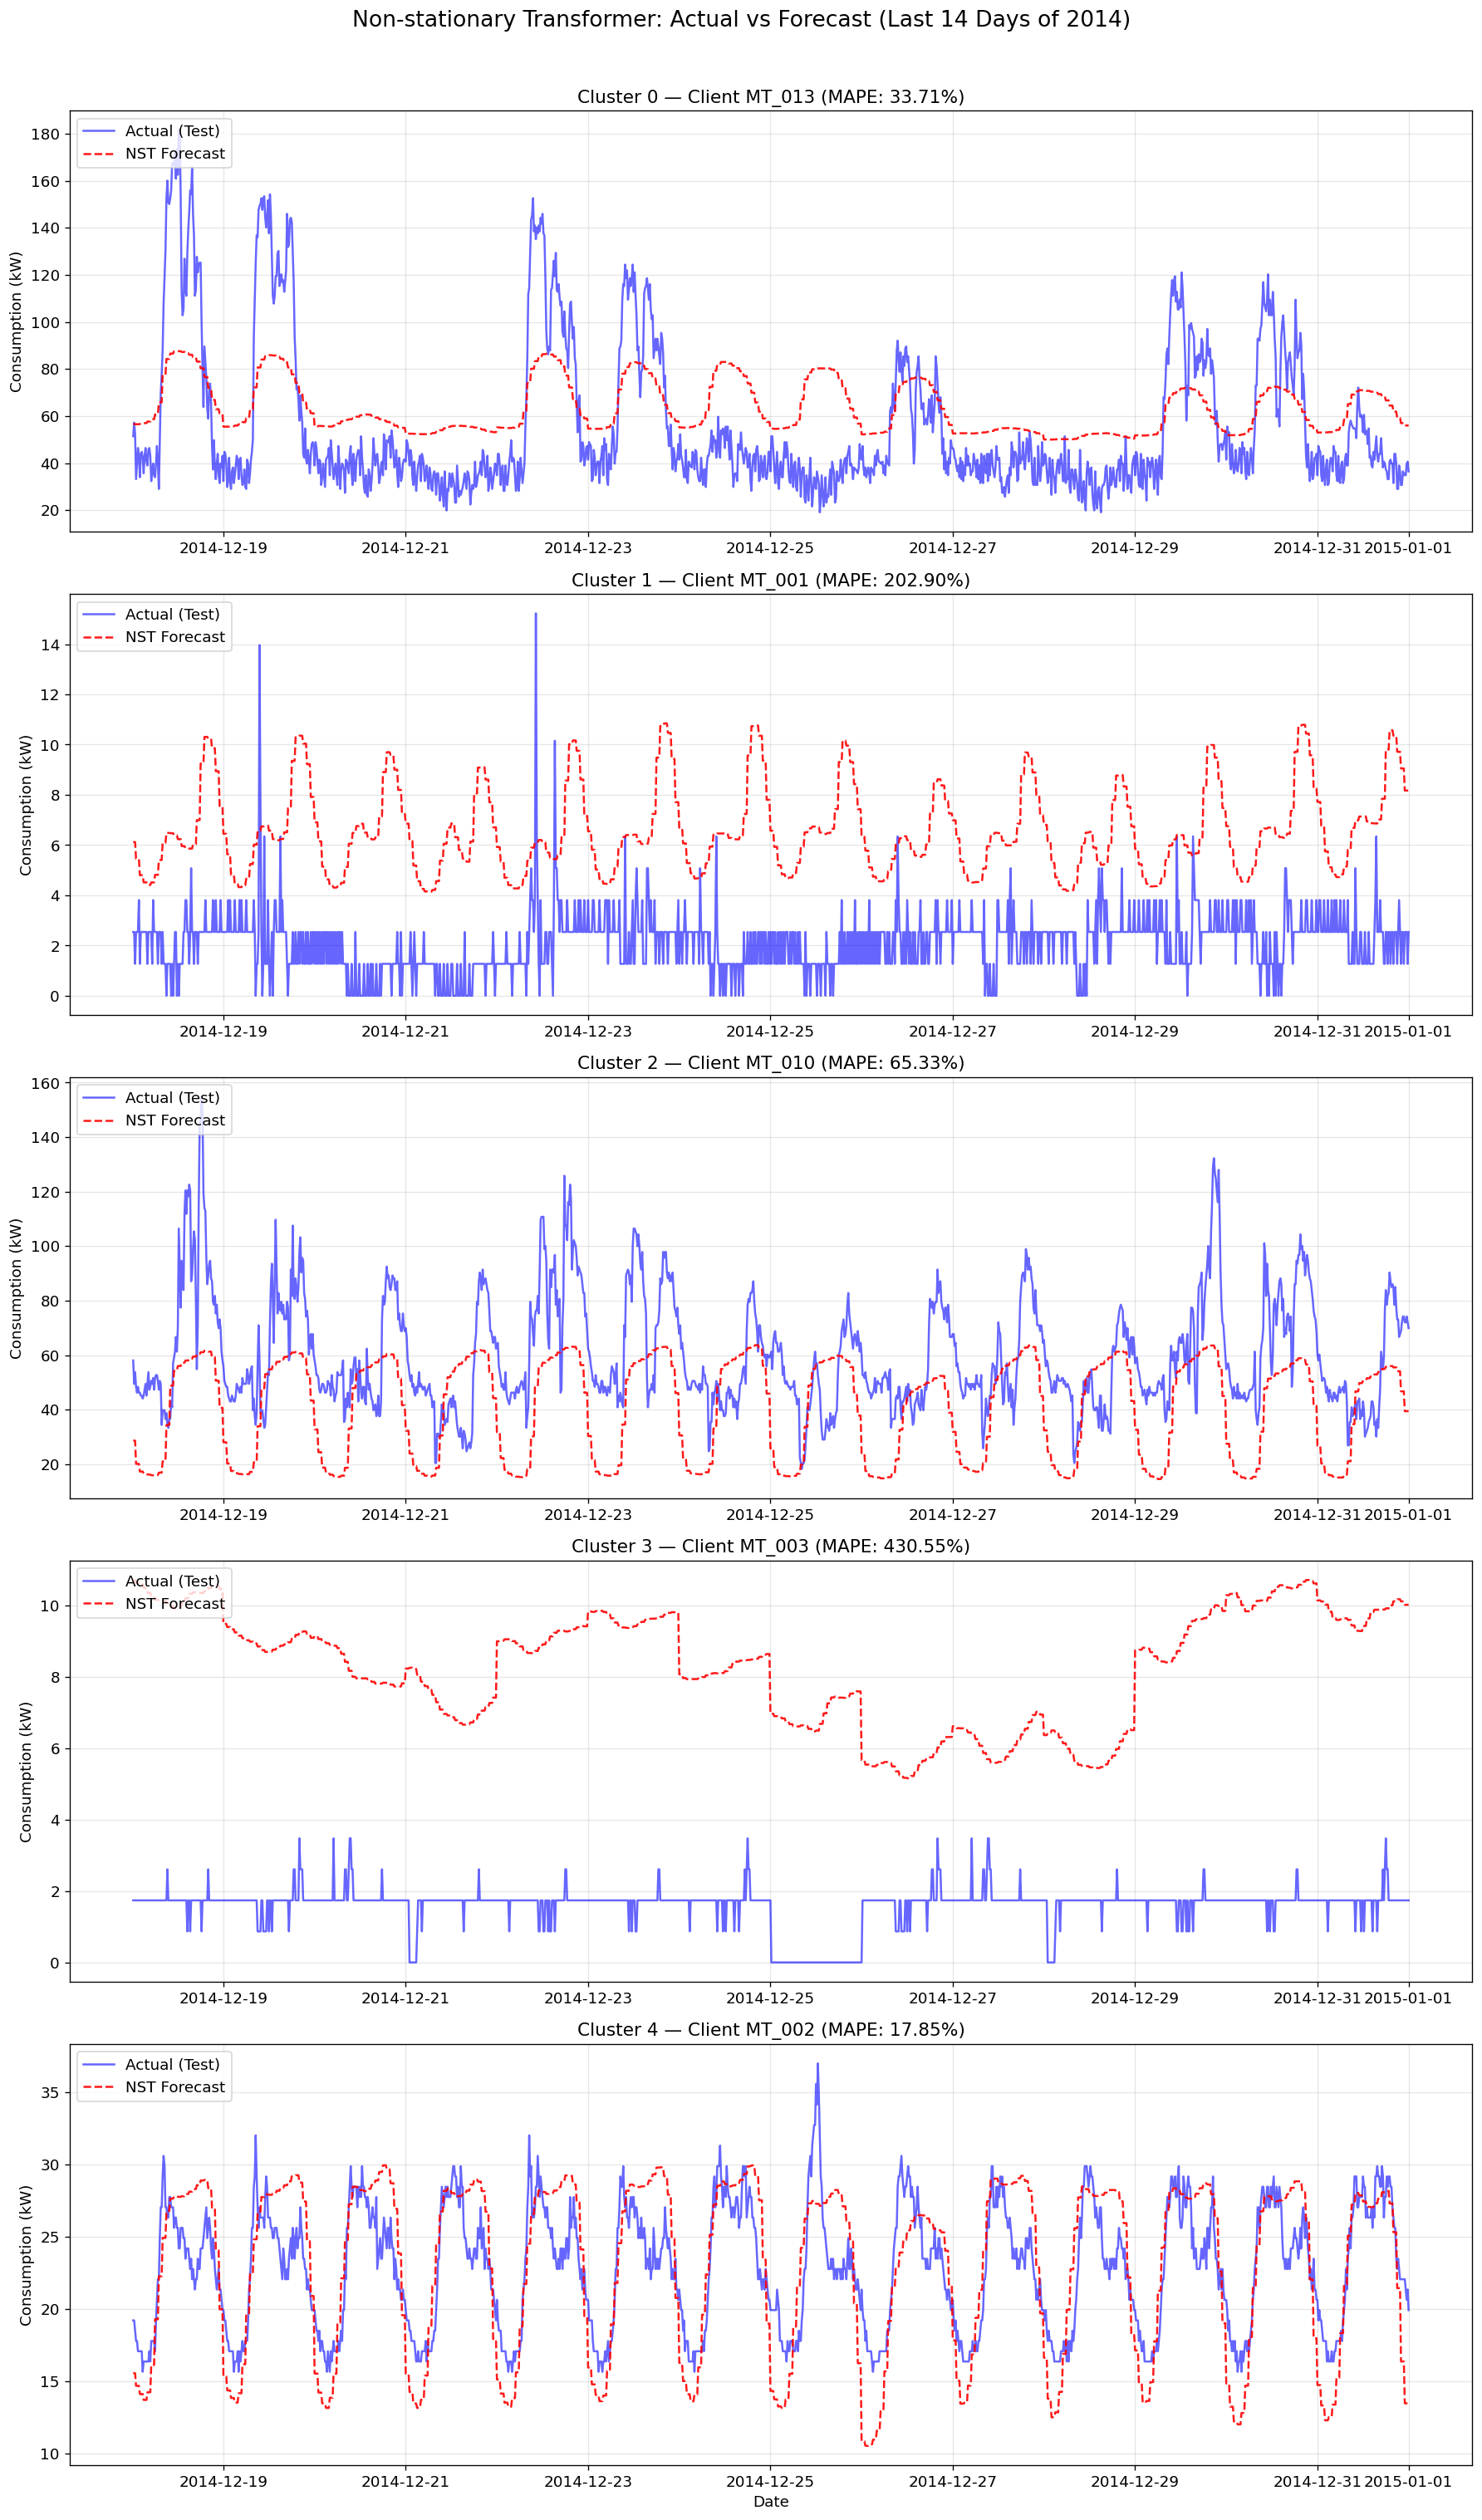

In [6]:
# =============================================================
# VISUALIZATION: ONE CLIENT PER CLUSTER (last 14 days of 2014)
# =============================================================
print("Generating validation plots...")

cluster_representatives = test.groupby('Cluster')['ClientID'].first().to_dict()

fig, axes = plt.subplots(len(cluster_representatives), 1, figsize=(15, 5 * len(cluster_representatives)))
if len(cluster_representatives) == 1:
    axes = [axes]

for idx, (cluster_id, client_id) in enumerate(sorted(cluster_representatives.items())):
    ax = axes[idx]
    
    client_data = test[test['ClientID'] == client_id].copy()
    y_actual = client_data['Consumption'].values
    y_pred   = client_data['Predicted_kW'].values
    dates    = client_data['Date'].values
    
    # Individual MAPE for this client
    nz = y_actual > 0.1
    client_mape = np.mean(np.abs((y_actual[nz] - y_pred[nz]) / y_actual[nz])) * 100 if nz.sum() > 0 else 0.0
    
    # Last 14 days (1344 steps at 15-min)
    plot_slice = -1344
    
    ax.plot(dates[plot_slice:], y_actual[plot_slice:],
            label='Actual (Test)', color='blue', alpha=0.6)
    ax.plot(dates[plot_slice:], y_pred[plot_slice:],
            label='NST Forecast', color='red', linestyle='--', alpha=0.9)
    
    ax.set_title(f'Cluster {int(cluster_id)} — Client {client_id} (MAPE: {client_mape:.2f}%)')
    ax.set_ylabel('Consumption (kW)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.suptitle("Non-stationary Transformer: Actual vs Forecast (Last 14 Days of 2014)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()